Saved: diagnostic_01_pigment_heatmap.png

--- Raw observation NA counts (across all date x depth rows) ---
# A tibble: 8 × 4
  pigment    n_NA n_total pct_NA
  <chr>     <int>   <int>  <dbl>
1 Fuco         35    1598    2.2
2 Perid       566    1598   35.4
3 Allo        797    1598   49.9
4 But_fuco    157    1598    9.8
5 Hex_fuco     39    1598    2.4
6 Zea         189    1598   11.8
7 Tot_Chl_b   251    1598   15.7
8 Tot_Chl_a   100    1598    6.3


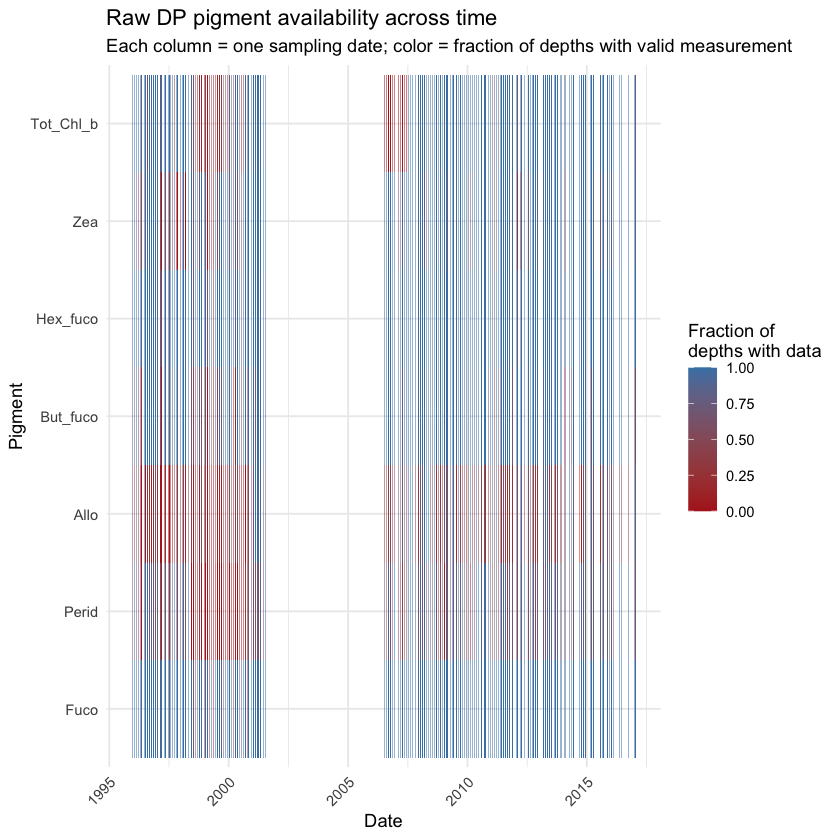

Saved: diagnostic_02_na_per_pigment.png

--- Culprit analysis: which pigments cause DP2 to be NA? ---
Total date x depth rows where DP2 is NA: 1029 out of 1598 
# A tibble: 7 × 3
  pigment   co_culprit_count sole_culprit_count
  <chr>                <int>              <int>
1 Allo                   797                318
2 Perid                  566                 98
3 Tot_Chl_b              251                 40
4 Zea                    189                 18
5 But_fuco               157                 28
6 Hex_fuco                39                  0
7 Fuco                    35                  0


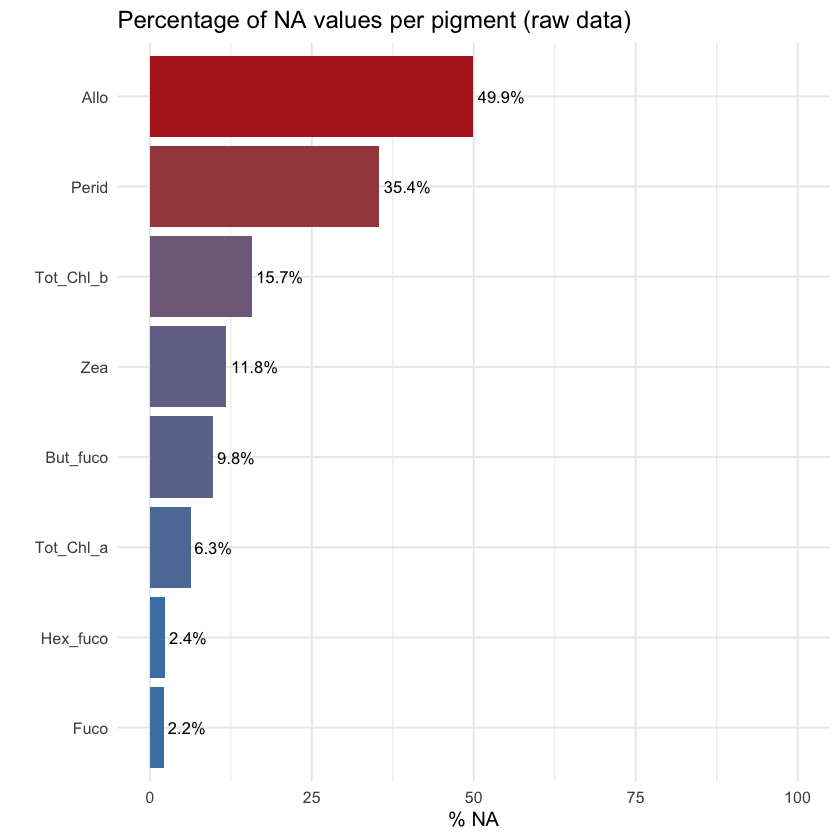

Saved: diagnostic_03_dp2_culprits.png


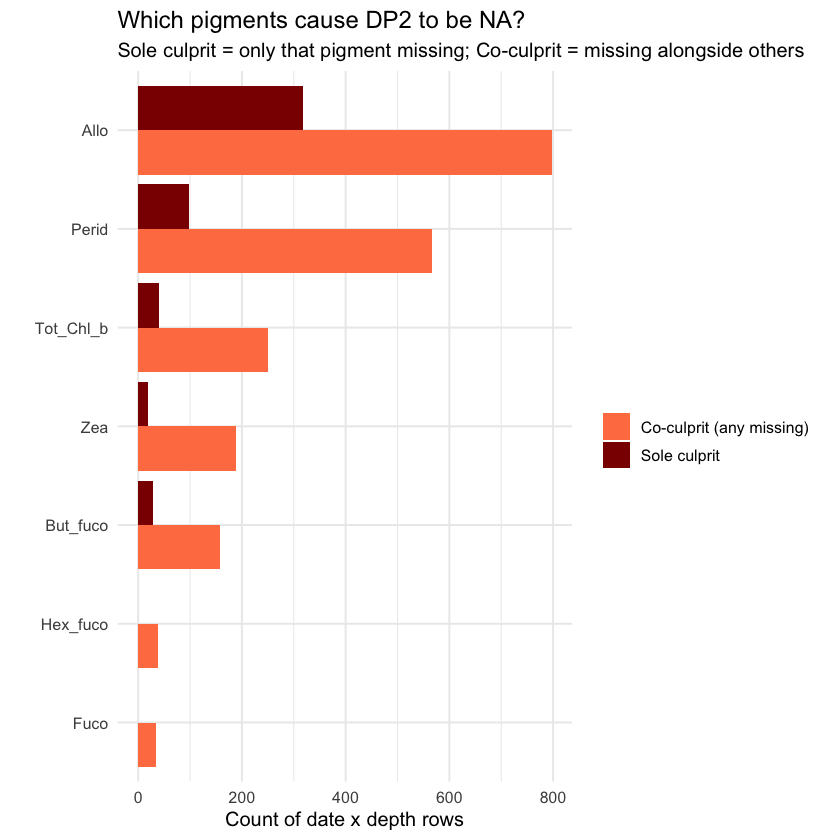

Saved: diagnostic_04_dp_coverage_timeline.png

HPLC_interpolated.RDS not found — running processHPLC.R inline.
If you haven't run it yet, run processHPLC.R first, then re-run this script.


Lade nötiges Paket: gsw



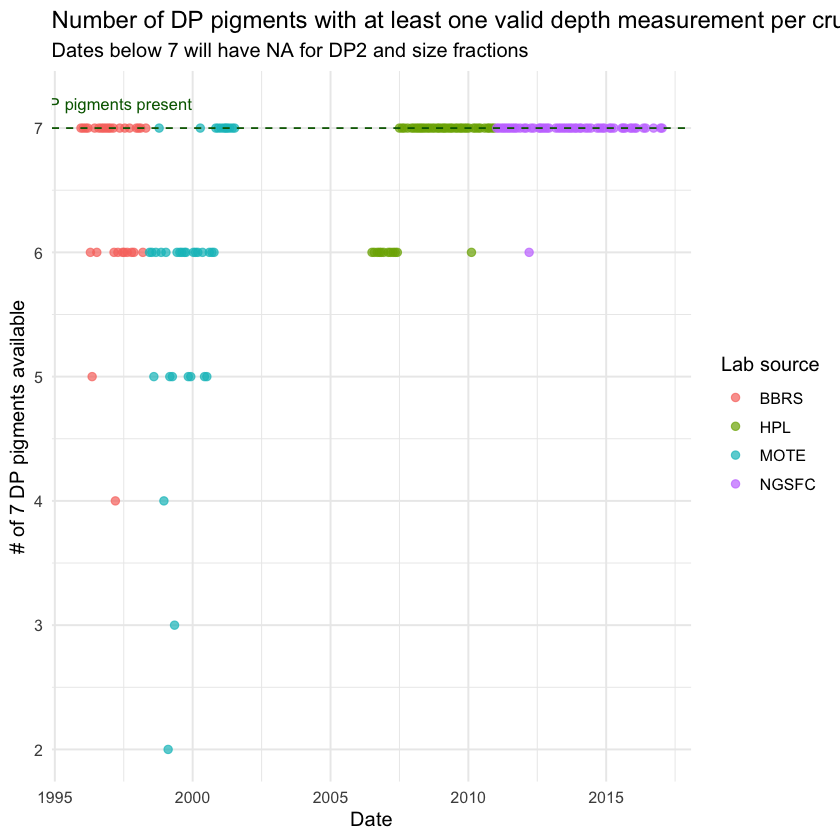

Saved: diagnostic_05_interpolated_na_heatmap.png


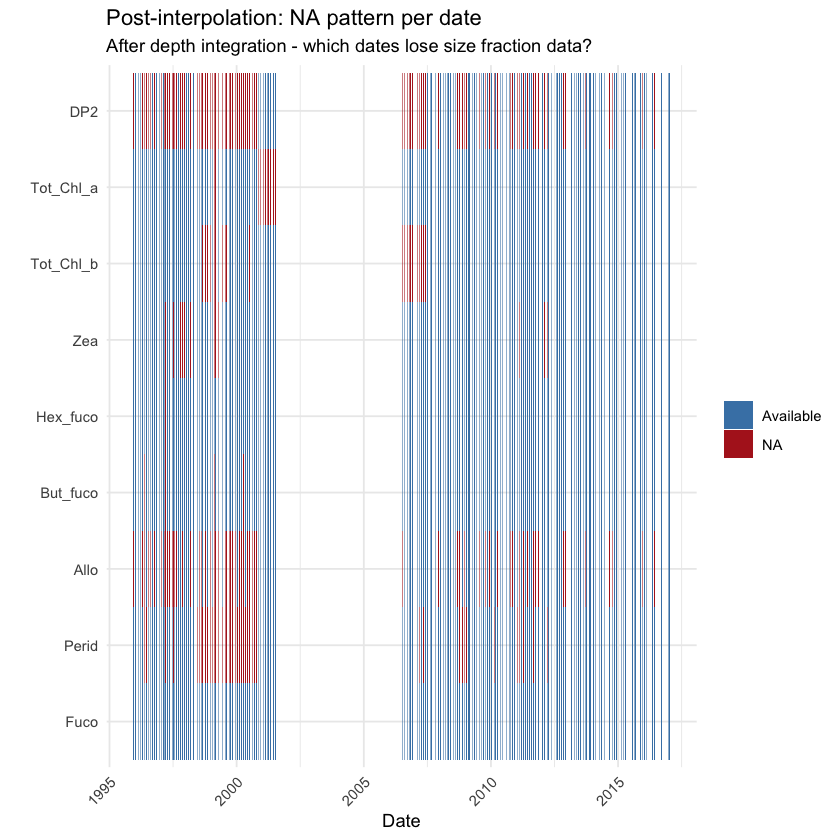

Saved: diagnostic_06_size_fractions.png

COVERAGE SUMMARY
Raw sampling dates:                  176
Dates after interpolation:           175
Dates with valid Tot_Chl_a:          164 (94%)
Dates with valid DP2 (size frac):    87 (50%)
Dates with both (absolute biomass):  78 (45%)
Dates LOST to DP2 NA:                88 (50%)


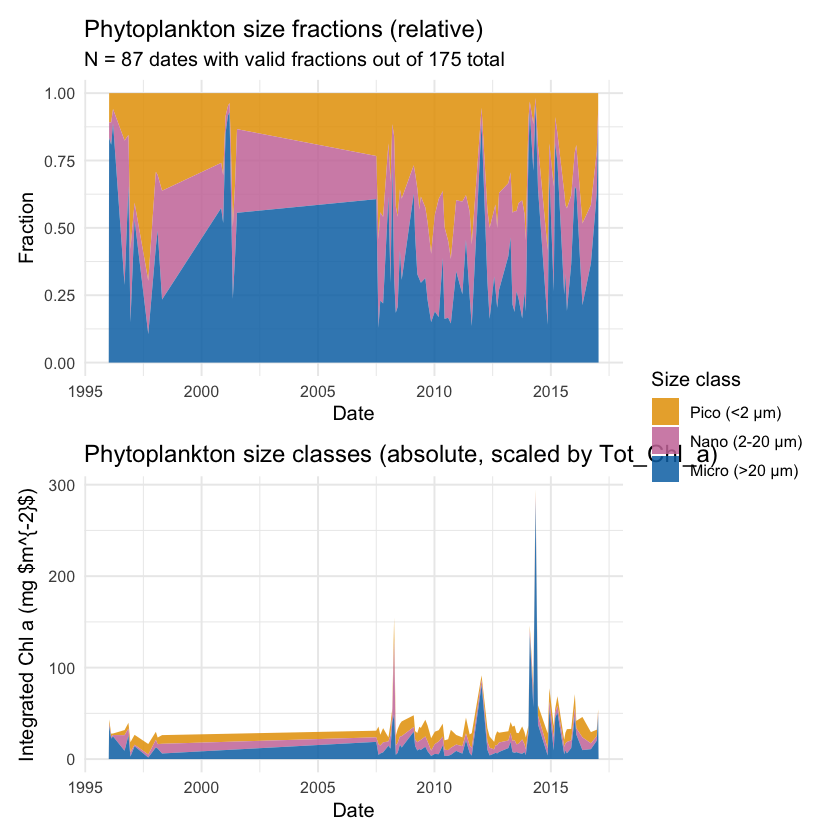

In [2]:
library(tidyverse)
library(patchwork)  # install.packages("patchwork") if needed

# =============================================================================
# 1. LOAD AND PREPARE RAW DATA (same as processHPLC.R)
# =============================================================================

hplc_bbrs  <- read.csv("../BCO-DMO/hplc_bbrs.csv", na.strings = "nd")
hplc_mote  <- read.csv("../BCO-DMO/hplc_mote.csv", na.strings = "nd")
hplc_hpl   <- read.csv("../BCO-DMO/hplc_hpl.csv", na.strings = "nd")
hplc_ngsfc <- read.csv("../BCO-DMO/hplc_ngsfc.csv", na.strings = "nd")

hplc_bbrs$source  <- "BBRS"
hplc_mote$source  <- "MOTE"
hplc_hpl$source   <- "HPL"
hplc_ngsfc$source <- "NGSFC"

pigments <- c("Pras", "Lut", "Fuco", "Perid", "Allo", "But_fuco",
              "Hex_fuco", "Zea", "Tot_Chl_b", "DP", "Tot_Chl_a",
              "TChl", "Chl_c1c2", "Chl_c3")

# The 7 diagnostic pigments needed for DP / size fractions
dp_pigments <- c("Fuco", "Perid", "Allo", "But_fuco", "Hex_fuco", "Zea", "Tot_Chl_b")

fulldat <- c(pigments, "Date", "depth", "source")

HPLC_ds <- rbind(hplc_bbrs[fulldat],
                 hplc_mote[fulldat],
                 hplc_hpl[fulldat],
                 hplc_ngsfc[fulldat])

HPLC_ds$date <- as.Date(as.character(HPLC_ds$Date), format = "%Y%m%d")
HPLC_ds <- HPLC_ds %>% select(-Date)
HPLC_ds[pigments][HPLC_ds[pigments] < 0] <- NA

# =============================================================================
# 2. RAW DATA: PIGMENT COVERAGE HEATMAP (per date x depth)
# =============================================================================

# For each date x depth, check which DP pigments are available
raw_coverage <- HPLC_ds %>%
  select(date, depth, source, all_of(dp_pigments)) %>%
  pivot_longer(cols = all_of(dp_pigments), names_to = "pigment", values_to = "value") %>%
  mutate(available = !is.na(value))

# --- Plot 2a: Heatmap of pigment availability across all dates ---
p_heatmap <- raw_coverage %>%
  # Average across depths: proportion of depths with data per date x pigment
  group_by(date, pigment) %>%
  summarise(frac_available = mean(available), .groups = "drop") %>%
  mutate(pigment = factor(pigment, levels = dp_pigments)) %>%
  ggplot(aes(x = date, y = pigment, fill = frac_available)) +
  geom_tile() +
  scale_fill_gradient(low = "firebrick", high = "steelblue",
                      name = "Fraction of\ndepths with data") +
  labs(title = "Raw DP pigment availability across time",
       subtitle = "Each column = one sampling date; color = fraction of depths with valid measurement",
       x = "Date", y = "Pigment") +
  theme_minimal(base_size = 11) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

print(p_heatmap)
#ggsave("diagnostic_01_pigment_heatmap.png", p_heatmap, width = 14, height = 4, dpi = 150)
cat("Saved: diagnostic_01_pigment_heatmap.png\n")

# --- Plot 2b: Per-pigment NA count across all observations ---
na_summary <- HPLC_ds %>%
  select(all_of(dp_pigments), Tot_Chl_a) %>%
  summarise(across(everything(), ~sum(is.na(.x)))) %>%
  pivot_longer(everything(), names_to = "pigment", values_to = "n_NA") %>%
  mutate(n_total = nrow(HPLC_ds),
         pct_NA = round(100 * n_NA / n_total, 1))

cat("\n--- Raw observation NA counts (across all date x depth rows) ---\n")
print(na_summary)

p_na_bar <- na_summary %>%
  mutate(pigment = fct_reorder(pigment, pct_NA)) %>%
  ggplot(aes(x = pigment, y = pct_NA, fill = pct_NA)) +
  geom_col() +
  geom_text(aes(label = paste0(pct_NA, "%")), hjust = -0.1, size = 3.5) +
  scale_fill_gradient(low = "steelblue", high = "firebrick", guide = "none") +
  coord_flip() +
  ylim(0, 100) +
  labs(title = "Percentage of NA values per pigment (raw data)",
       x = "", y = "% NA") +
  theme_minimal(base_size = 12)

print(p_na_bar)
#ggsave("diagnostic_02_na_per_pigment.png", p_na_bar, width = 7, height = 5, dpi = 150)
cat("Saved: diagnostic_02_na_per_pigment.png\n")

# =============================================================================
# 3. WHICH PIGMENTS CAUSE DP2 TO BE NA?
# =============================================================================

# For each date x depth, flag whether each DP pigment is missing,
# and whether DP2 would be NA (= any of the 7 is NA)

dp_diagnosis <- HPLC_ds %>%
  select(date, depth, source, all_of(dp_pigments)) %>%
  mutate(
    DP2_available = complete.cases(across(all_of(dp_pigments))),
    # Which pigment(s) are the "culprit" when DP2 is NA?
    across(all_of(dp_pigments), ~is.na(.x), .names = "missing_{.col}")
  )

# Count how often each pigment is the sole reason DP2 is NA
culprit_analysis <- dp_diagnosis %>%
  filter(!DP2_available) %>%
  select(starts_with("missing_")) %>%
  # For each NA row, count how many pigments are missing
  mutate(n_missing = rowSums(across(everything()))) %>%
  # Cases where exactly 1 pigment is missing (sole culprit)
  filter(n_missing == 1) %>%
  select(-n_missing) %>%
  summarise(across(everything(), sum)) %>%
  pivot_longer(everything(), names_to = "pigment", values_to = "sole_culprit_count") %>%
  mutate(pigment = str_remove(pigment, "missing_"))

# Also count how often each pigment is missing among all NA-DP2 rows (co-culprit)
co_culprit <- dp_diagnosis %>%
  filter(!DP2_available) %>%
  select(starts_with("missing_")) %>%
  summarise(across(everything(), sum)) %>%
  pivot_longer(everything(), names_to = "pigment", values_to = "co_culprit_count") %>%
  mutate(pigment = str_remove(pigment, "missing_"))

culprit_combined <- left_join(co_culprit, culprit_analysis, by = "pigment") %>%
  replace_na(list(sole_culprit_count = 0)) %>%
  mutate(total_DP2_NA = sum(!dp_diagnosis$DP2_available))

cat("\n--- Culprit analysis: which pigments cause DP2 to be NA? ---\n")
cat("Total date x depth rows where DP2 is NA:", culprit_combined$total_DP2_NA[1], 
    "out of", nrow(dp_diagnosis), "\n")
print(culprit_combined %>% select(-total_DP2_NA) %>% arrange(desc(co_culprit_count)))

p_culprit <- culprit_combined %>%
  pivot_longer(cols = c(co_culprit_count, sole_culprit_count),
               names_to = "type", values_to = "count") %>%
  mutate(pigment = fct_reorder(pigment, count, .fun = max),
         type = ifelse(type == "sole_culprit_count", "Sole culprit", "Co-culprit (any missing)")) %>%
  ggplot(aes(x = pigment, y = count, fill = type)) +
  geom_col(position = "dodge") +
  coord_flip() +
  scale_fill_manual(values = c("Co-culprit (any missing)" = "coral", "Sole culprit" = "darkred")) +
  labs(title = "Which pigments cause DP2 to be NA?",
       subtitle = "Sole culprit = only that pigment missing; Co-culprit = missing alongside others",
       x = "", y = "Count of date x depth rows", fill = "") +
  theme_minimal(base_size = 12)

print(p_culprit)
#ggsave("diagnostic_03_dp2_culprits.png", p_culprit, width = 9, height = 5, dpi = 150)
cat("Saved: diagnostic_03_dp2_culprits.png\n")

# =============================================================================
# 4. COVERAGE OVER TIME: DP2 availability by source
# =============================================================================

# After depth-aggregation (mimicking the mesh step), check per-date availability
date_coverage <- HPLC_ds %>%
  select(date, source, all_of(dp_pigments), Tot_Chl_a) %>%
  group_by(date, source) %>%
  # For each date: are ALL 7 DP pigments measured at ANY depth?
  summarise(
    across(all_of(dp_pigments), ~any(!is.na(.x))),
    Tot_Chl_a_available = any(!is.na(Tot_Chl_a)),
    .groups = "drop"
  ) %>%
  mutate(
    all_DP_available = Fuco & Perid & Allo & But_fuco & Hex_fuco & Zea & Tot_Chl_b,
    n_DP_available = Fuco + Perid + Allo + But_fuco + Hex_fuco + Zea + Tot_Chl_b
  )

p_timeline <- date_coverage %>%
  ggplot(aes(x = date, y = n_DP_available, color = source)) +
  geom_point(size = 2, alpha = 0.7) +
  geom_hline(yintercept = 7, linetype = "dashed", color = "darkgreen", linewidth = 0.5) +
  annotate("text", x = min(date_coverage$date) + 200, y = 7.2, 
           label = "All 7 DP pigments present", color = "darkgreen", size = 3.5) +
  scale_y_continuous(breaks = 0:7) +
  labs(title = "Number of DP pigments with at least one valid depth measurement per cruise",
       subtitle = "Dates below 7 will have NA for DP2 and size fractions",
       x = "Date", y = "# of 7 DP pigments available", color = "Lab source") +
  theme_minimal(base_size = 12)

print(p_timeline)
#ggsave("diagnostic_04_dp_coverage_timeline.png", p_timeline, width = 12, height = 5, dpi = 150)
cat("Saved: diagnostic_04_dp_coverage_timeline.png\n")

# =============================================================================
# 5. POST-INTERPOLATION: LOAD PROCESSED DATA AND SHOW SIZE FRACTION COVERAGE
# =============================================================================

# Load the processed data if available, otherwise compute inline
if (file.exists("processed/HPLC_interpolated_sizes.rds")) {
  hplc_final <- readRDS("processed/HPLC_interpolated_sizes.rds")
} else {
  cat("\nHPLC_interpolated.RDS not found — running processHPLC.R inline.\n")
  cat("If you haven't run it yet, run processHPLC.R first, then re-run this script.\n")
  
  # Minimal inline version for diagnostics
  source('../interpolateData.r')
  
  Mesh_HPLC <- HPLC_ds %>%
    select(date, depth, all_of(pigments)) %>%
    group_by(date, depth) %>%
    summarise(across(everything(), ~mean(.x, na.rm = TRUE)), .groups = "drop")
  
  hplc_temp_store <- list()
  for (variable in pigments) {
    hplc_temp_store[[variable]] <- interpolateData(
      Mesh_HPLC, variable, noofNA = 70, output_type = 'integrated')
    names(hplc_temp_store[[variable]])[1] <- variable
  }
  hplc_ds_cleaned <- hplc_temp_store %>% reduce(full_join, by = "date")
  
  hplc_final <- hplc_ds_cleaned %>%
    mutate(
      DP2 = 1.41 * Fuco + 1.41 * Perid + 0.60 * Allo +
            0.35 * But_fuco + 1.27 * Hex_fuco + 0.86 * Zea + 1.01 * Tot_Chl_b,
      DP2 = ifelse(DP2 < 0.001, NA, DP2),
      micro = (1.41 * Fuco + 1.41 * Perid) / DP2,
      nano  = (0.60 * Allo + 0.35 * But_fuco + 1.27 * Hex_fuco) / DP2,
      pico  = (0.86 * Zea + 1.01 * Tot_Chl_b) / DP2
    )
}

# --- Plot 5a: Interpolated pigment NA status per date ---
interp_na <- hplc_final %>%
  select(date, all_of(dp_pigments), Tot_Chl_a, DP2) %>%
  mutate(across(-date, ~is.na(.x))) %>%
  pivot_longer(-date, names_to = "variable", values_to = "is_na") %>%
  mutate(variable = factor(variable, levels = c(dp_pigments, "Tot_Chl_a", "DP2")))

p_interp_heatmap <- interp_na %>%
  ggplot(aes(x = date, y = variable, fill = is_na)) +
  geom_tile() +
  scale_fill_manual(values = c("TRUE" = "firebrick", "FALSE" = "steelblue"),
                    labels = c("TRUE" = "NA", "FALSE" = "Available"), name = "") +
  labs(title = "Post-interpolation: NA pattern per date",
       subtitle = "After depth integration - which dates lose size fraction data?",
       x = "Date", y = "") +
  theme_minimal(base_size = 11) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

print(p_interp_heatmap)
#ggsave("diagnostic_05_interpolated_na_heatmap.png", p_interp_heatmap, width = 14, height = 4, dpi = 150)
cat("Saved: diagnostic_05_interpolated_na_heatmap.png\n")

# --- Plot 5b: Size fraction time series with gaps visible ---
sf_long <- hplc_final %>%
  select(date, micro, nano, pico, Tot_Chl_a) %>%
  filter(!is.na(micro)) %>%
  pivot_longer(cols = c(micro, nano, pico), names_to = "size_class", values_to = "fraction") %>%
  mutate(size_class = factor(size_class, levels = c("pico", "nano", "micro"),
                             labels = c("Pico (<2 µm)", "Nano (2-20 µm)", "Micro (>20 µm)")))

p_sf_stack <- ggplot(sf_long, aes(x = date, y = fraction, fill = size_class)) +
  geom_area(position = "stack", alpha = 0.85) +
  scale_fill_manual(values = c("Pico (<2 µm)" = "#E69F00", 
                               "Nano (2-20 µm)" = "#CC79A7",
                               "Micro (>20 µm)" = "#0072B2")) +
  labs(title = "Phytoplankton size fractions (relative)",
       subtitle = paste0("N = ", sum(!is.na(hplc_final$micro)), " dates with valid fractions out of ", 
                         nrow(hplc_final), " total"),
       x = "Date", y = "Fraction", fill = "Size class") +
  theme_minimal(base_size = 12)

# Absolute biomass per size class
sf_abs <- hplc_final %>%
  select(date, micro, nano, pico, Tot_Chl_a) %>%
  filter(!is.na(micro) & !is.na(Tot_Chl_a)) %>%
  mutate(micro_abs = micro * Tot_Chl_a,
         nano_abs  = nano  * Tot_Chl_a,
         pico_abs  = pico  * Tot_Chl_a) %>%
  pivot_longer(cols = c(micro_abs, nano_abs, pico_abs), 
               names_to = "size_class", values_to = "chl_a") %>%
  mutate(size_class = factor(size_class, levels = c("pico_abs", "nano_abs", "micro_abs"),
                             labels = c("Pico (<2 µm)", "Nano (2-20 µm)", "Micro (>20 µm)")))

p_sf_abs <- ggplot(sf_abs, aes(x = date, y = chl_a, fill = size_class)) +
  geom_area(position = "stack", alpha = 0.85) +
  scale_fill_manual(values = c("Pico (<2 µm)" = "#E69F00", 
                               "Nano (2-20 µm)" = "#CC79A7",
                               "Micro (>20 µm)" = "#0072B2")) +
  labs(title = "Phytoplankton size classes (absolute, scaled by Tot_Chl_a)",
       x = "Date", y = "Integrated Chl a (mg $m^{-2}$)", fill = "Size class") +
  theme_minimal(base_size = 12)

p_combined_sf <- p_sf_stack / p_sf_abs + plot_layout(guides = "collect")
print(p_combined_sf)
#ggsave("diagnostic_06_size_fractions.png", p_combined_sf, width = 12, height = 8, dpi = 150)
cat("Saved: diagnostic_06_size_fractions.png\n")

# =============================================================================
# 6. SUMMARY TABLE
# =============================================================================

cat("\n========================================================\n")
cat("COVERAGE SUMMARY\n")
cat("========================================================\n")

n_total_dates <- length(unique(HPLC_ds$date))
n_interp_dates <- nrow(hplc_final)
n_with_dp2 <- sum(!is.na(hplc_final$DP2))
n_with_chla <- sum(!is.na(hplc_final$Tot_Chl_a))
n_with_both <- sum(!is.na(hplc_final$DP2) & !is.na(hplc_final$Tot_Chl_a))

cat(sprintf("Raw sampling dates:                  %d\n", n_total_dates))
cat(sprintf("Dates after interpolation:           %d\n", n_interp_dates))
cat(sprintf("Dates with valid Tot_Chl_a:          %d (%.0f%%)\n", n_with_chla, 100*n_with_chla/n_interp_dates))
cat(sprintf("Dates with valid DP2 (size frac):    %d (%.0f%%)\n", n_with_dp2, 100*n_with_dp2/n_interp_dates))
cat(sprintf("Dates with both (absolute biomass):  %d (%.0f%%)\n", n_with_both, 100*n_with_both/n_interp_dates))
cat(sprintf("Dates LOST to DP2 NA:                %d (%.0f%%)\n", n_interp_dates - n_with_dp2, 100*(n_interp_dates - n_with_dp2)/n_interp_dates))
cat("========================================================\n")